# RQ3 — Lock vs Motor / Transmission Signal

## Research question

> Is the true-gate ranking signal specific to the lock-contact channel, or is comparable information also present in the motor / transmission reference channel?

RQ1 established acoustic feasibility and RQ2 showed that shackle loading improves true-digit ranking. RQ3 now tests source specificity.

### Data

- controlled `RQ1-4` dataset
- password: **3517**
- wheels: **W1, W2 and W4**
- direction: **CCW**
- **loaded scans only**
- 10 scans per wheel, 10 candidates per scan
- total: **30 scans / 300 movements**
- simultaneous target/contact and motor-reference recordings

### Competing explanations

- **Lock-specific hypothesis:** useful true-gate information should be substantially stronger in the target/contact channel than in the motor-reference channel.
- **Shared mechanical-path hypothesis:** both channels can contain useful information because lock loading and drivetrain behaviour are mechanically coupled.

### Controlled comparison

The same leave-one-scan-out ranking pipeline is run with five fixed feature sets:

1. Target only — 13 features
2. Reference only — 13 features
3. Cross only — 3 cross-channel features
4. Target + Reference — 26 features
5. All — 29 features

The primary source-validity test is the **paired target-only vs reference-only true-digit rank** on the same 30 scans. Lower rank is better.

The reference microphone should not be treated as a perfectly isolated “motor-noise control”: mechanical load changes can propagate through the drivetrain. RQ3 therefore tests **channel specificity**, not exact physical localisation of the acoustic source.

## 1. Load the controlled dataset and shared feature cache

In [12]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

MYDRIVE = Path("/content/drive/MyDrive")
PROJECT_ROOT = MYDRIVE / "Padlock_Reproduction_v1"

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT / "Padlock_Reproduction_v1" / "results",
]

RESULTS_ROOT = next(
    (
        p for p in results_candidates
        if (p / "00_RQ1-4_QC" / "RQ1-4_qc_manifest.csv").exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate Padlock_Reproduction_v1/results."
    )

QC_MANIFEST = (
    RESULTS_ROOT
    / "00_RQ1-4_QC"
    / "RQ1-4_qc_manifest.csv"
)

CACHE_PATH = (
    RESULTS_ROOT
    / "feature_cache"
    / "RQ1-4_interpretable_v1.npz"
)

RESULT_DIR = (
    RESULTS_ROOT
    / "03_RQ3_Lock_vs_Motor_Noise"
)

RESULT_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(QC_MANIFEST)
cache = np.load(CACHE_PATH, allow_pickle=False)

X = cache["X"]
feature_names = cache["feature_names"].astype(str)
cache_run_ids = cache["run_ids"].astype(str)

if not np.array_equal(
    manifest["run_id"].astype(str).to_numpy(),
    cache_run_ids,
):
    raise RuntimeError(
        "Cache run order does not match the QC manifest."
    )

assert len(manifest) == 600
assert X.shape == (600, 29)
assert manifest["quality_valid"].all()
assert manifest["position_valid"].all()

feature_df = manifest.copy()

for j, name in enumerate(feature_names):
    feature_df[name] = X[:, j]

loaded = feature_df[
    feature_df["tension_state"] == "LOADED"
].copy()

assert len(loaded) == 300
assert loaded["scan_id"].nunique() == 30

print("Loaded candidates:", len(loaded))
print("Loaded scans     :", loaded["scan_id"].nunique())
print("Feature count    :", len(feature_names))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded candidates: 300
Loaded scans     : 30
Feature count    : 29


## 2. Fixed channel feature groups and leave-one-scan-out ranking

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import rankdata

target_features = [
    name for name in feature_names
    if name.startswith("target_")
]

reference_features = [
    name for name in feature_names
    if name.startswith("reference_")
]

cross_features = [
    name for name in feature_names
    if name.startswith("cross_")
]

feature_groups = {
    "Target only": target_features,
    "Reference only": reference_features,
    "Cross only": cross_features,
    "Target + Reference": target_features + reference_features,
    "All": target_features + reference_features + cross_features,
}

for group_name, features in feature_groups.items():
    print(f"{group_name:20s} {len(features):2d} features")


def evaluate_feature_group(group_name, features):
    rows = []

    for wheel in [1, 2, 4]:
        wheel_data = loaded[
            loaded["wheel"] == wheel
        ].copy()

        scan_ids = sorted(
            wheel_data["scan_id"].unique()
        )

        if len(scan_ids) != 10:
            raise RuntimeError(
                f"W{wheel}: expected 10 scans."
            )

        for test_scan in scan_ids:
            train = wheel_data[
                wheel_data["scan_id"] != test_scan
            ]

            test = wheel_data[
                wheel_data["scan_id"] == test_scan
            ]

            model = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    C=1.0,
                    solver="liblinear",
                    class_weight="balanced",
                    max_iter=2000,
                    random_state=0,
                ),
            )

            model.fit(
                train[features].to_numpy(dtype=float),
                train["is_true_gate"].to_numpy(dtype=int),
            )

            scores = model.predict_proba(
                test[features].to_numpy(dtype=float)
            )[:, 1]

            ranks = rankdata(
                -scores,
                method="average",
            )

            true_mask = (
                test["is_true_gate"].to_numpy(dtype=int)
                == 1
            )

            true_rank = float(
                ranks[true_mask][0]
            )

            rows.append({
                "feature_group": group_name,
                "wheel": wheel,
                "scan_id": int(test_scan),
                "scan_start_digit": int(
                    test["scan_start_digit"].iloc[0]
                ),
                "true_rank": true_rank,
                "top1": int(true_rank <= 1),
                "top2": int(true_rank <= 2),
                "top3": int(true_rank <= 3),
                "predicted_digit": int(
                    test.iloc[int(np.argmax(scores))]["after_digit"]
                ),
            })

    return pd.DataFrame(rows)


rq3_predictions = pd.concat(
    [
        evaluate_feature_group(group_name, features)
        for group_name, features in feature_groups.items()
    ],
    ignore_index=True,
)

rq3_predictions.to_csv(
    RESULT_DIR / "RQ3_predictions.csv",
    index=False,
)

print("Prediction rows:", len(rq3_predictions))

Target only          13 features
Reference only       13 features
Cross only            3 features
Target + Reference   26 features
All                  29 features
Prediction rows: 150


## 3. Overall channel performance and evidence against random ranking

In [14]:
from scipy.stats import binomtest


def exact_uniform_rank_p(ranks):
    ranks = np.asarray(ranks, dtype=int)
    n = len(ranks)
    observed_sum = int(ranks.sum())

    distribution = np.array([1], dtype=object)
    kernel = np.zeros(11, dtype=object)
    kernel[1:11] = 1

    for _ in range(n):
        distribution = np.convolve(
            distribution,
            kernel,
        )

    return float(
        sum(distribution[:observed_sum + 1])
        / (10 ** n)
    )


summary_rows = []
chance_rows = []

for group_name in feature_groups:
    group_predictions = rq3_predictions[
        rq3_predictions["feature_group"] == group_name
    ]

    for scope in [1, 2, 4, "Overall"]:
        if scope == "Overall":
            g = group_predictions
            scope_label = "Overall"
        else:
            g = group_predictions[
                group_predictions["wheel"] == scope
            ]
            scope_label = f"W{scope}"

        summary_rows.append({
            "feature_group": group_name,
            "scope": scope_label,
            "n_scans": len(g),
            "top1": g["top1"].mean(),
            "top2": g["top2"].mean(),
            "top3": g["top3"].mean(),
            "mean_true_rank": g["true_rank"].mean(),
            "median_true_rank": g["true_rank"].median(),
        })

    chance_rows.append({
        "feature_group": group_name,
        "n_scans": len(group_predictions),
        "mean_true_rank": group_predictions["true_rank"].mean(),
        "top1": group_predictions["top1"].mean(),
        "top2": group_predictions["top2"].mean(),
        "top3": group_predictions["top3"].mean(),
        "rank_p_vs_random": exact_uniform_rank_p(
            group_predictions["true_rank"].to_numpy()
        ),
        "top1_p_vs_random": binomtest(
            int(group_predictions["top1"].sum()),
            len(group_predictions),
            0.10,
            alternative="greater",
        ).pvalue,
        "top2_p_vs_random": binomtest(
            int(group_predictions["top2"].sum()),
            len(group_predictions),
            0.20,
            alternative="greater",
        ).pvalue,
        "top3_p_vs_random": binomtest(
            int(group_predictions["top3"].sum()),
            len(group_predictions),
            0.30,
            alternative="greater",
        ).pvalue,
    })

rq3_summary = pd.DataFrame(summary_rows)
channel_chance_tests = pd.DataFrame(chance_rows)

rq3_summary.to_csv(
    RESULT_DIR / "RQ3_channel_performance.csv",
    index=False,
)

channel_chance_tests.to_csv(
    RESULT_DIR / "RQ3_chance_tests.csv",
    index=False,
)

display(channel_chance_tests.round(4))

,feature_group,n_scans,mean_true_rank,top1,top2,top3,rank_p_vs_random,top1_p_vs_random,top2_p_vs_random,top3_p_vs_random
0,Target only,30,3.5000,0.1667,0.4333,0.7000,0.0001,0.1755,0.0031,0.0000
1,Reference only,30,3.8333,0.1667,0.3333,0.5000,0.0007,0.1755,0.0611,0.0169
2,Cross only,30,4.0000,0.1667,0.3333,0.5333,0.0022,0.1755,0.0611,0.0064
3,Target + Reference,30,3.4667,0.2000,0.4000,0.6000,0.0000,0.0732,0.0095,0.0006
4,All,30,3.2000,0.2667,0.4333,0.7667,0.0000,0.0078,0.0031,0.0000


## 4. Primary source-validity test: target/contact vs motor-reference

The two channel-specific models are compared on the same 30 scans.

For each scan,

\[
\Delta r = r_{\mathrm{reference}} - r_{\mathrm{target}}
\]

so a positive value means that the target/contact channel ranked the true digit better. The primary test is a one-sided paired Wilcoxon test. Wheel-specific p-values are Holm-corrected across W1/W2/W4.

In [15]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


def bootstrap_mean_ci(values, seed=20260819, n_boot=30000):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)

    indices = rng.integers(
        0,
        len(values),
        size=(n_boot, len(values)),
    )

    means = values[indices].mean(axis=1)

    return np.quantile(
        means,
        [0.025, 0.975],
    )


target_rank = rq3_predictions[
    rq3_predictions["feature_group"] == "Target only"
][
    [
        "wheel",
        "scan_start_digit",
        "true_rank",
        "top1",
        "top2",
        "top3",
    ]
].rename(
    columns={
        "true_rank": "target_rank",
        "top1": "target_top1",
        "top2": "target_top2",
        "top3": "target_top3",
    }
)

reference_rank = rq3_predictions[
    rq3_predictions["feature_group"] == "Reference only"
][
    [
        "wheel",
        "scan_start_digit",
        "true_rank",
        "top1",
        "top2",
        "top3",
    ]
].rename(
    columns={
        "true_rank": "reference_rank",
        "top1": "reference_top1",
        "top2": "reference_top2",
        "top3": "reference_top3",
    }
)

channel_pairs = target_rank.merge(
    reference_rank,
    on=["wheel", "scan_start_digit"],
    validate="one_to_one",
)

if len(channel_pairs) != 30:
    raise RuntimeError(
        f"Expected 30 matched scans, found {len(channel_pairs)}"
    )

channel_pairs["target_advantage"] = (
    channel_pairs["reference_rank"]
    - channel_pairs["target_rank"]
)

channel_pairs.to_csv(
    RESULT_DIR / "RQ3_target_reference_pairs.csv",
    index=False,
)

pair_rows = []

for i, (scope, group) in enumerate([
    ("W1", channel_pairs[channel_pairs["wheel"] == 1]),
    ("W2", channel_pairs[channel_pairs["wheel"] == 2]),
    ("W4", channel_pairs[channel_pairs["wheel"] == 4]),
    ("Overall", channel_pairs),
]):
    _, p_value = wilcoxon(
        group["target_rank"],
        group["reference_rank"],
        alternative="less",
        method="auto",
    )

    ci_low, ci_high = bootstrap_mean_ci(
        group["target_advantage"].to_numpy(),
        seed=20260819 + i,
    )

    pair_rows.append({
        "scope": scope,
        "n_pairs": len(group),
        "target_mean_rank": group["target_rank"].mean(),
        "reference_mean_rank": group["reference_rank"].mean(),
        "mean_target_advantage": group["target_advantage"].mean(),
        "advantage_ci_low": ci_low,
        "advantage_ci_high": ci_high,
        "median_target_advantage": group["target_advantage"].median(),
        "target_better": int((group["target_advantage"] > 0).sum()),
        "same_rank": int((group["target_advantage"] == 0).sum()),
        "reference_better": int((group["target_advantage"] < 0).sum()),
        "p_raw_target_better": p_value,
    })

channel_tests = pd.DataFrame(pair_rows)
channel_tests["p_holm_wheels"] = np.nan

wheel_mask = channel_tests["scope"] != "Overall"

channel_tests.loc[
    wheel_mask,
    "p_holm_wheels",
] = multipletests(
    channel_tests.loc[
        wheel_mask,
        "p_raw_target_better",
    ],
    method="holm",
)[1]

channel_tests.to_csv(
    RESULT_DIR / "RQ3_target_reference_tests.csv",
    index=False,
)

display(channel_tests.round(4))

,scope,n_pairs,target_mean_rank,reference_mean_rank,mean_target_advantage,advantage_ci_low,advantage_ci_high,median_target_advantage,target_better,same_rank,reference_better,p_raw_target_better,p_holm_wheels
0,W1,10,3.4,3.8000,0.4000,-2.1,3.1,-0.5,4,1,5,0.4219,0.8438
1,W2,10,4.5,3.4000,-1.1000,-2.6,0.3,-1.0,3,0,7,0.8555,0.8555
2,W4,10,2.6,4.3000,1.7000,0.4,3.1,1.0,7,1,2,0.0332,0.0996
3,Overall,30,3.5,3.8333,0.3333,-0.8,1.5,0.0,14,2,14,0.3107,NaN


## 5. Do the channels add complementary information?

In [16]:
all_rank = rq3_predictions[
    rq3_predictions["feature_group"] == "All"
][
    ["wheel", "scan_start_digit", "true_rank"]
].rename(
    columns={"true_rank": "all_rank"}
)

all_vs_target = target_rank[
    ["wheel", "scan_start_digit", "target_rank"]
].merge(
    all_rank,
    on=["wheel", "scan_start_digit"],
    validate="one_to_one",
)

all_vs_target["all_advantage"] = (
    all_vs_target["target_rank"]
    - all_vs_target["all_rank"]
)

_, p_all_vs_target = wilcoxon(
    all_vs_target["all_rank"],
    all_vs_target["target_rank"],
    alternative="less",
    method="auto",
)

all_vs_target.to_csv(
    RESULT_DIR / "RQ3_all_vs_target_pairs.csv",
    index=False,
)

all_vs_target_summary = pd.DataFrame([{
    "n_pairs": len(all_vs_target),
    "target_mean_rank": all_vs_target["target_rank"].mean(),
    "all_mean_rank": all_vs_target["all_rank"].mean(),
    "mean_all_advantage": all_vs_target["all_advantage"].mean(),
    "median_all_advantage": all_vs_target["all_advantage"].median(),
    "all_better_fraction": np.mean(
        all_vs_target["all_rank"]
        < all_vs_target["target_rank"]
    ),
    "p_all_better": p_all_vs_target,
}])

all_vs_target_summary.to_csv(
    RESULT_DIR / "RQ3_all_vs_target_test.csv",
    index=False,
)

display(all_vs_target_summary.round(4))

,n_pairs,target_mean_rank,all_mean_rank,mean_all_advantage,median_all_advantage,all_better_fraction,p_all_better
0,30,3.5,3.2,0.3,0.0,0.4,0.1828


## 6. Main figures

The figures are chosen around the RQ rather than around a fixed chart template:

1. the complete ranking curves show whether each channel contains usable information;
2. the dumbbell plot directly compares target/contact and reference mean rank by wheel;
3. matched-scan outcomes show whether either channel wins consistently.

Figure titles are left to the report caption.

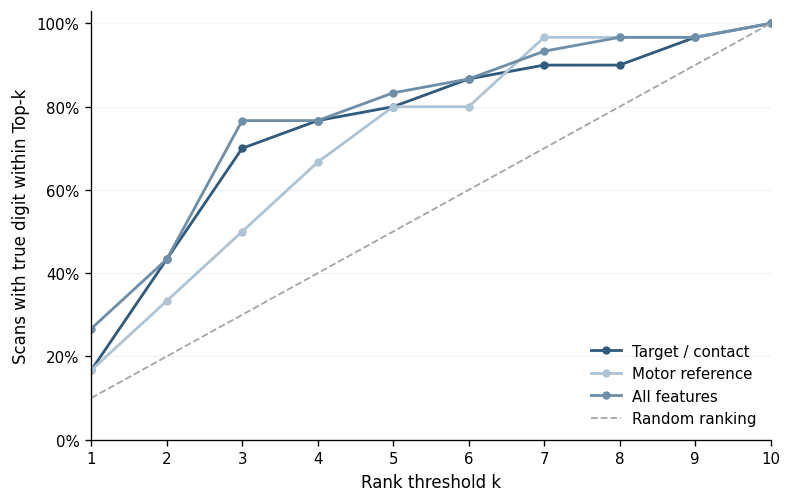

In [17]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DARK_BLUE = "#315B7D"
MID_BLUE = "#6F8FA8"
LIGHT_BLUE = "#AFC5D5"
PALE_BLUE = "#DCE8F0"
LIGHT_GREY = "#D9DDE0"
MID_GREY = "#A1A7AC"
DARK_GREY = "#596168"


def save_figure(fig, stem):
    fig.savefig(
        RESULT_DIR / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        RESULT_DIR / f"{stem}.pdf",
        bbox_inches="tight",
    )


def cumulative_curve(frame):
    ranks = frame["true_rank"].to_numpy(dtype=float)
    ks = np.arange(1, 11)
    values = np.array([
        np.mean(ranks <= k)
        for k in ks
    ])
    return ks, values


fig, ax = plt.subplots(figsize=(6.7, 4.3))

for group_name, color, label in [
    ("Target only", DARK_BLUE, "Target / contact"),
    ("Reference only", LIGHT_BLUE, "Motor reference"),
    ("All", MID_BLUE, "All features"),
]:
    ks, values = cumulative_curve(
        rq3_predictions[
            rq3_predictions["feature_group"] == group_name
        ]
    )

    ax.plot(
        ks,
        100 * values,
        marker="o",
        markersize=4,
        linewidth=1.7,
        color=color,
        label=label,
    )

ax.plot(
    np.arange(1, 11),
    10 * np.arange(1, 11),
    linestyle="--",
    linewidth=1.1,
    color=MID_GREY,
    label="Random ranking",
)

ax.set_xlim(1, 10)
ax.set_ylim(0, 103)
ax.set_xticks(np.arange(1, 11))
ax.set_yticks(np.arange(0, 101, 20))
ax.set_yticklabels([
    f"{value}%"
    for value in np.arange(0, 101, 20)
])
ax.set_xlabel("Rank threshold k")
ax.set_ylabel("Scans with true digit within Top-k")
ax.grid(axis="y", alpha=0.13)
ax.legend(frameon=False, loc="lower right")

fig.tight_layout()

save_figure(
    fig,
    "RQ3_Fig1_channel_rank_curves",
)

plt.show()

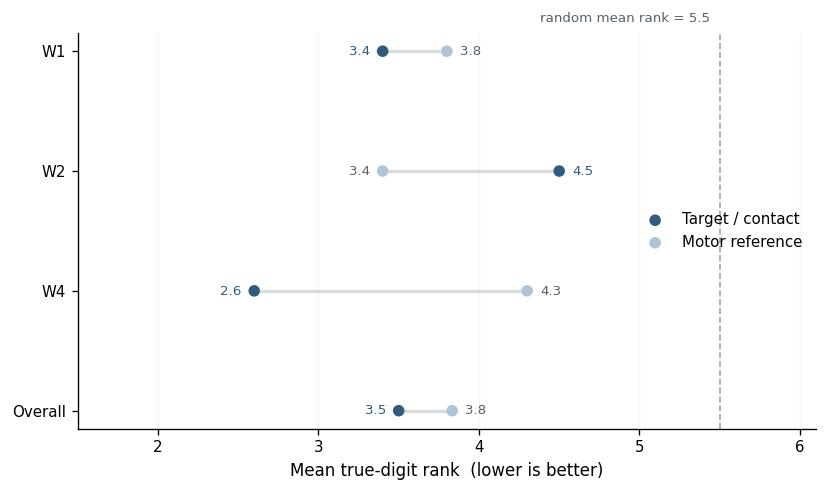

In [18]:
# Figure 2 — direct target/contact vs motor-reference comparison

plot_order = ["W1", "W2", "W4", "Overall"]
y = np.arange(len(plot_order))

fig, ax = plt.subplots(figsize=(7.0, 4.2))

for i, scope in enumerate(plot_order):
    row = channel_tests[
        channel_tests["scope"] == scope
    ].iloc[0]

    target_value = row["target_mean_rank"]
    reference_value = row["reference_mean_rank"]

    ax.plot(
        [target_value, reference_value],
        [i, i],
        color=LIGHT_GREY,
        linewidth=2,
        zorder=1,
    )

    ax.scatter(
        target_value,
        i,
        s=48,
        color=DARK_BLUE,
        edgecolor="none",
        zorder=3,
        label="Target / contact" if i == 0 else None,
    )

    ax.scatter(
        reference_value,
        i,
        s=48,
        color=LIGHT_BLUE,
        edgecolor="none",
        zorder=3,
        label="Motor reference" if i == 0 else None,
    )

    if target_value <= reference_value:
        ax.text(
            target_value - 0.08,
            i,
            f"{target_value:.1f}",
            ha="right",
            va="center",
            fontsize=8,
            color=DARK_BLUE,
        )
        ax.text(
            reference_value + 0.08,
            i,
            f"{reference_value:.1f}",
            ha="left",
            va="center",
            fontsize=8,
            color=DARK_GREY,
        )
    else:
        ax.text(
            reference_value - 0.08,
            i,
            f"{reference_value:.1f}",
            ha="right",
            va="center",
            fontsize=8,
            color=DARK_GREY,
        )
        ax.text(
            target_value + 0.08,
            i,
            f"{target_value:.1f}",
            ha="left",
            va="center",
            fontsize=8,
            color=DARK_BLUE,
        )

ax.axvline(
    5.5,
    color=MID_GREY,
    linestyle="--",
    linewidth=1,
)

ax.text(
    5.44,
    -0.22,
    "random mean rank = 5.5",
    ha="right",
    va="bottom",
    fontsize=8,
    color=DARK_GREY,
)

ax.set_yticks(y)
ax.set_yticklabels(plot_order)
ax.invert_yaxis()
ax.set_xlim(1.5, 6.1)
ax.set_xlabel("Mean true-digit rank  (lower is better)")
ax.grid(axis="x", alpha=0.12)

ax.legend(
    frameon=False,
    ncol=1,
    loc="center right",
)

fig.tight_layout()

save_figure(
    fig,
    "RQ3_Fig2_target_vs_reference_rank",
)

plt.show()

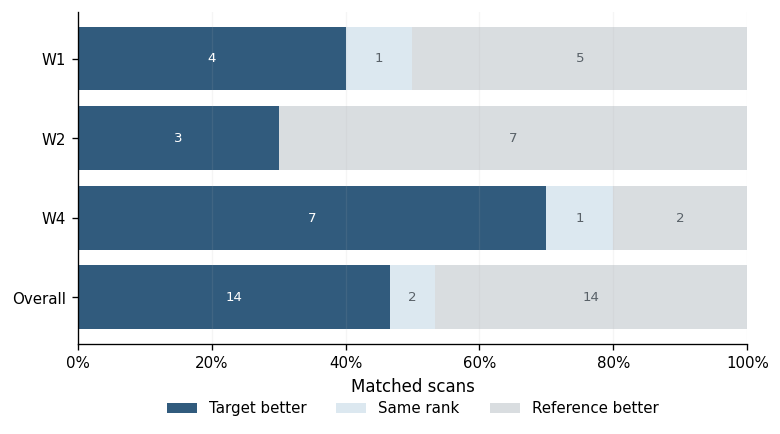

In [19]:
# Figure 3 — matched-scan consistency

outcome_plot = channel_tests[
    [
        "scope",
        "target_better",
        "same_rank",
        "reference_better",
        "n_pairs",
    ]
].copy()

for column in [
    "target_better",
    "same_rank",
    "reference_better",
]:
    outcome_plot[f"{column}_pct"] = (
        100
        * outcome_plot[column]
        / outcome_plot["n_pairs"]
    )

fig, ax = plt.subplots(figsize=(7.2, 4.2))

y = np.arange(len(outcome_plot))
left = np.zeros(len(outcome_plot))

for column, label, color in [
    ("target_better_pct", "Target better", DARK_BLUE),
    ("same_rank_pct", "Same rank", PALE_BLUE),
    ("reference_better_pct", "Reference better", LIGHT_GREY),
]:
    values = outcome_plot[column].to_numpy()

    ax.barh(
        y,
        values,
        left=left,
        color=color,
        edgecolor="none",
        label=label,
    )

    count_column = column.replace("_pct", "")
    counts = outcome_plot[count_column].to_numpy()

    for yi, left_value, width, count in zip(
        y,
        left,
        values,
        counts,
    ):
        if width >= 5:
            ax.text(
                left_value + width / 2,
                yi,
                str(int(count)),
                ha="center",
                va="center",
                fontsize=8,
                color=(
                    "white"
                    if column == "target_better_pct"
                    else DARK_GREY
                ),
            )

    left += values

ax.set_yticks(y)
ax.set_yticklabels(outcome_plot["scope"])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 20))
ax.set_xticklabels([
    f"{value}%"
    for value in np.arange(0, 101, 20)
])
ax.set_xlabel("Matched scans")
ax.grid(axis="x", alpha=0.12)

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
)

fig.subplots_adjust(bottom=0.22)

save_figure(
    fig,
    "RQ3_Fig3_paired_channel_outcomes",
)

plt.show()

## 7. Report tables

In [20]:
table1 = channel_chance_tests[
    [
        "feature_group",
        "mean_true_rank",
        "top1",
        "top2",
        "top3",
        "rank_p_vs_random",
    ]
].copy()

table1["mean_true_rank"] = table1["mean_true_rank"].map(
    lambda x: f"{x:.2f}"
)

for column in ["top1", "top2", "top3"]:
    table1[column] = (100 * table1[column]).map(
        lambda x: f"{x:.1f}%"
    )

table1["rank_p_vs_random"] = table1["rank_p_vs_random"].map(
    lambda x: "<0.001" if x < 0.001 else f"{x:.3f}"
)

table1 = table1.rename(columns={
    "feature_group": "Feature group",
    "mean_true_rank": "Mean rank",
    "top1": "Top-1",
    "top2": "Top-2",
    "top3": "Top-3",
    "rank_p_vs_random": "Rank p vs random",
})

table1.to_csv(
    RESULT_DIR / "RQ3_Table1_channel_performance.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ3_Table1_channel_performance.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table1.to_latex(index=False, escape=True)
    )

display(table1)

,Feature group,Mean rank,Top-1,Top-2,Top-3,Rank p vs random
0,Target only,3.50,16.7%,43.3%,70.0%,<0.001
1,Reference only,3.83,16.7%,33.3%,50.0%,<0.001
2,Cross only,4.00,16.7%,33.3%,53.3%,0.002
3,Target + Reference,3.47,20.0%,40.0%,60.0%,<0.001
4,All,3.20,26.7%,43.3%,76.7%,<0.001


In [21]:
table2 = channel_tests.copy()

table2["Target mean rank"] = table2["target_mean_rank"].map(
    lambda x: f"{x:.2f}"
)

table2["Reference mean rank"] = table2["reference_mean_rank"].map(
    lambda x: f"{x:.2f}"
)

table2["Mean advantage (Target)"] = table2["mean_target_advantage"].map(
    lambda x: f"{x:+.2f}"
)

table2["95% CI"] = [
    f"[{low:+.2f}, {high:+.2f}]"
    for low, high in zip(
        table2["advantage_ci_low"],
        table2["advantage_ci_high"],
    )
]

table2["Paired outcome"] = [
    f"{target}/{same}/{reference}"
    for target, same, reference in zip(
        table2["target_better"],
        table2["same_rank"],
        table2["reference_better"],
    )
]

table2["p"] = table2["p_raw_target_better"].map(
    lambda x: f"{x:.3f}"
)

table2["Holm p"] = table2["p_holm_wheels"].map(
    lambda x: "" if pd.isna(x) else f"{x:.3f}"
)

table2 = table2[
    [
        "scope",
        "n_pairs",
        "Target mean rank",
        "Reference mean rank",
        "Mean advantage (Target)",
        "95% CI",
        "Paired outcome",
        "p",
        "Holm p",
    ]
].rename(columns={
    "scope": "Scope",
    "n_pairs": "N pairs",
})

table2.to_csv(
    RESULT_DIR / "RQ3_Table2_target_reference_tests.csv",
    index=False,
)

with open(
    RESULT_DIR / "RQ3_Table2_target_reference_tests.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table2.to_latex(index=False, escape=True)
    )

display(table2)

,Scope,N pairs,Target mean rank,Reference mean rank,Mean advantage (Target),95% CI,Paired outcome,p,Holm p
0,W1,10,3.40,3.80,+0.40,"[-2.10, +3.10]",4/1/5,0.422,0.844
1,W2,10,4.50,3.40,-1.10,"[-2.60, +0.30]",3/0/7,0.855,0.855
2,W4,10,2.60,4.30,+1.70,"[+0.40, +3.10]",7/1/2,0.033,0.100
3,Overall,30,3.50,3.83,+0.33,"[-0.80, +1.50]",14/2/14,0.311,


## 8. Result record

In [22]:
overall_channel = channel_tests[
    channel_tests["scope"] == "Overall"
].iloc[0]

target_result = channel_chance_tests[
    channel_chance_tests["feature_group"] == "Target only"
].iloc[0]

reference_result = channel_chance_tests[
    channel_chance_tests["feature_group"] == "Reference only"
].iloc[0]

all_result = channel_chance_tests[
    channel_chance_tests["feature_group"] == "All"
].iloc[0]

w4_result = channel_tests[
    channel_tests["scope"] == "W4"
].iloc[0]

rq3_conclusion = {
    "research_question": (
        "Is the true-gate ranking signal specific to the lock-contact channel, "
        "or is comparable information present in the motor/transmission reference channel?"
    ),
    "dataset": "RQ1-4 controlled acoustic validity dataset, loaded scans only",
    "password": "3517",
    "direction": "CCW",
    "wheels": [1, 2, 4],
    "n_scans": 30,
    "target_only": {
        "mean_rank": float(target_result["mean_true_rank"]),
        "top3": float(target_result["top3"]),
        "rank_p_vs_random": float(target_result["rank_p_vs_random"]),
    },
    "reference_only": {
        "mean_rank": float(reference_result["mean_true_rank"]),
        "top3": float(reference_result["top3"]),
        "rank_p_vs_random": float(reference_result["rank_p_vs_random"]),
    },
    "target_vs_reference": {
        "target_mean_rank": float(overall_channel["target_mean_rank"]),
        "reference_mean_rank": float(overall_channel["reference_mean_rank"]),
        "mean_target_advantage": float(overall_channel["mean_target_advantage"]),
        "target_better": int(overall_channel["target_better"]),
        "same_rank": int(overall_channel["same_rank"]),
        "reference_better": int(overall_channel["reference_better"]),
        "paired_wilcoxon_p": float(overall_channel["p_raw_target_better"]),
    },
    "all_features": {
        "mean_rank": float(all_result["mean_true_rank"]),
        "top3": float(all_result["top3"]),
        "rank_p_vs_random": float(all_result["rank_p_vs_random"]),
        "paired_p_vs_target_only": float(p_all_vs_target),
    },
    "interpretation": (
        "True-gate ranking information is present in both the target/contact channel "
        "and the motor-reference channel. The target channel is not significantly better "
        "overall than the reference channel, and the matched scan outcomes split evenly "
        "between target-better and reference-better cases. RQ3 therefore does not support "
        "a lock-contact-only source attribution. The most defensible interpretation is a "
        "mixed or mechanically coupled signal path: the reference channel can carry "
        "information about load-dependent mechanical events as well as motor/transmission sound."
    ),
    "wheel_heterogeneity": (
        f"W4 favours the target channel descriptively "
        f"({w4_result['target_mean_rank']:.1f} vs {w4_result['reference_mean_rank']:.1f} mean rank; "
        f"raw p={w4_result['p_raw_target_better']:.3f}), but this does not survive Holm correction "
        f"across the three wheels (p={w4_result['p_holm_wheels']:.3f}). W2 shows the opposite pattern."
    ),
    "complementarity": (
        "Using all target, reference and cross-channel features gives the best descriptive "
        "overall ranking (mean rank 3.20; Top-3 76.7%), but the paired improvement over "
        "target-only is not significant."
    ),
    "limitation": (
        "The motor-reference microphone is not a pure negative control for motor noise: "
        "mechanical load changes can propagate through the drivetrain and appear in the "
        "reference channel. This experiment tests channel specificity, but cannot uniquely "
        "localise the physical source of the informative event."
    ),
    "next_step": (
        "RQ4 tests whether the candidate-level structure is mechanically repeatable across "
        "controlled A/B repeats before later shortcut and context ablations."
    ),
}

with open(
    RESULT_DIR / "RQ3_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(rq3_conclusion, f, indent=2)

run_info = {
    "notebook": "03_RQ3_Lock_vs_Motor_Noise.ipynb",
    "feature_cache": str(CACHE_PATH),
    "loaded_scans": 30,
    "feature_groups": {
        name: len(features)
        for name, features in feature_groups.items()
    },
    "validation": "leave-one-scan-out separately within W1, W2 and W4",
    "classifier": {
        "type": "LogisticRegression",
        "C": 1.0,
        "solver": "liblinear",
        "class_weight": "balanced",
        "random_state": 0,
    },
    "primary_source_comparison": (
        "paired target/contact vs reference true-digit ranks on matched scans"
    ),
    "multiple_testing": (
        "Holm correction across W1/W2/W4 target-vs-reference tests"
    ),
    "note": "RQ3 source-validity experiment; not a MAIN model result.",
}

with open(
    RESULT_DIR / "RQ3_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(run_info, f, indent=2)

print(json.dumps(rq3_conclusion, indent=2))

print("\nSaved outputs:")
for path in sorted(RESULT_DIR.glob("RQ3_*")):
    print(" -", path.name)

{
  "research_question": "Is the true-gate ranking signal specific to the lock-contact channel, or is comparable information present in the motor/transmission reference channel?",
  "dataset": "RQ1-4 controlled acoustic validity dataset, loaded scans only",
  "password": "3517",
  "direction": "CCW",
  "wheels": [
    1,
    2,
    4
  ],
  "n_scans": 30,
  "target_only": {
    "mean_rank": 3.5,
    "top3": 0.7,
    "rank_p_vs_random": 5.5969175219011086e-05
  },
  "reference_only": {
    "mean_rank": 3.8333333333333335,
    "top3": 0.5,
    "rank_p_vs_random": 0.0007200198857997521
  },
  "target_vs_reference": {
    "target_mean_rank": 3.5,
    "reference_mean_rank": 3.8333333333333335,
    "mean_target_advantage": 0.3333333333333333,
    "target_better": 14,
    "same_rank": 2,
    "reference_better": 14,
    "paired_wilcoxon_p": 0.3106904799210739
  },
  "all_features": {
    "mean_rank": 3.2,
    "top3": 0.7666666666666667,
    "rank_p_vs_random": 3.5539730426672638e-06,
    "pair